# project setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/WiDSWorldWide_GlobalDathon26.zip -d /content/data

Archive:  /content/drive/MyDrive/WiDSWorldWide_GlobalDathon26.zip
  inflating: /content/data/metaData.csv  
  inflating: /content/data/sample_submission.csv  
  inflating: /content/data/test.csv  
  inflating: /content/data/train.csv  


In [4]:
train = pd.read_csv('data/train.csv')
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [5]:
test = pd.read_csv('data/test.csv')
test.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
1,13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
2,13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
3,16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
4,17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7


# EDA + feature engineering

<Axes: >

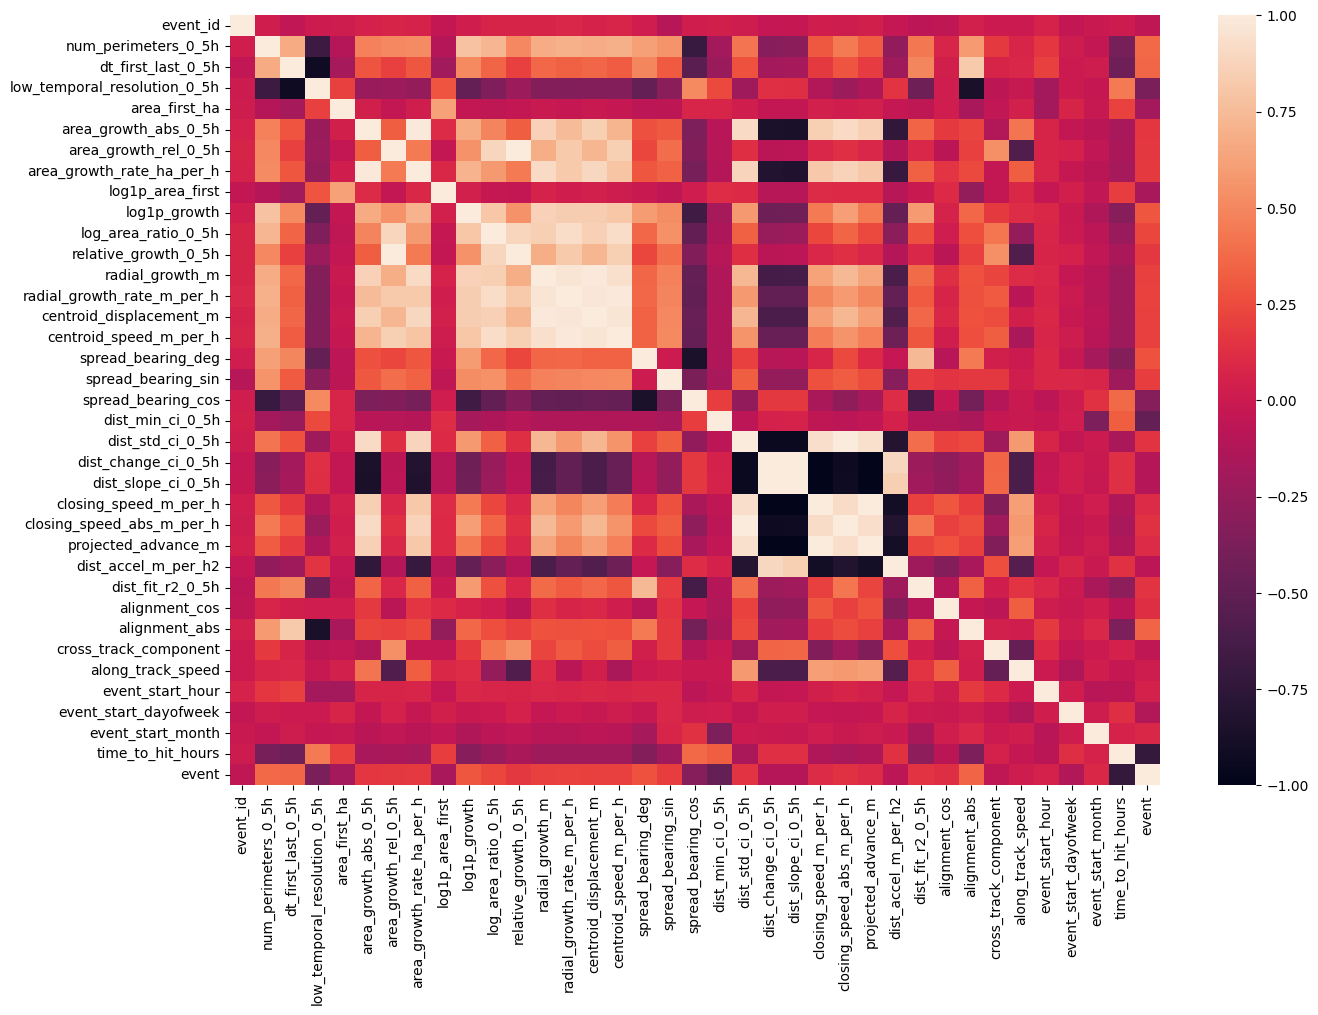

In [6]:
#vizualising correlation between features to get a good idea of what variables
#are independent from each other
corr_matrix = train.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix)

In [7]:
#getting the most influential features on time_to_hit_hours
time_corr = corr_matrix['time_to_hit_hours']
clean_time_corr = time_corr.drop(index=['time_to_hit_hours', 'event']).abs()
sorted_time_corr = clean_time_corr.sort_values(ascending=False)
sorted_time_corr.head(20)

,time_to_hit_hours
low_temporal_resolution_0_5h,0.442236
dt_first_last_0_5h,0.434699
num_perimeters_0_5h,0.392040
spread_bearing_cos,0.370451
alignment_abs,0.366923
spread_bearing_deg,0.335598
dist_min_ci_0_5h,0.324876
log1p_growth,0.317451
dist_fit_r2_0_5h,0.284143
log_area_ratio_0_5h,0.228119


In [8]:
#from the heatmap it's obvious that some features are just copies of one another
#or are super correlated so probably will have a negative effect on the
#generalizability of the NN

og_features = np.array(sorted_time_corr.index)
corr_no_targets = corr_matrix.drop(index=['time_to_hit_hours', 'event']).abs()

#storing the "duplicate" features in this list
feats_to_remove = set()

#given % to filter out features by
high_corr = 0.99


for feat in og_features:
  correlations = corr_no_targets[feat]
  corr_no_feat = correlations.drop(feat)
  high_correlations = corr_no_feat[lambda x: x > high_corr]
  #print(feat)
  #print(high_correlations)
  #print(len(high_correlations))

  if len(high_correlations) > 0:
    features = clean_time_corr[high_correlations.index]
    features[feat] = clean_time_corr[feat]
    max_feat = features.idxmax()
    feats_to_drop_later = features.drop(max_feat)
    feats_to_remove.update(feats_to_drop_later.index)

print(feats_to_remove)


{'area_growth_abs_0_5h', 'projected_advance_m', 'relative_growth_0_5h', 'closing_speed_m_per_h', 'dist_std_ci_0_5h', 'dist_slope_ci_0_5h', 'dist_change_ci_0_5h', 'area_growth_rel_0_5h'}


<Axes: >

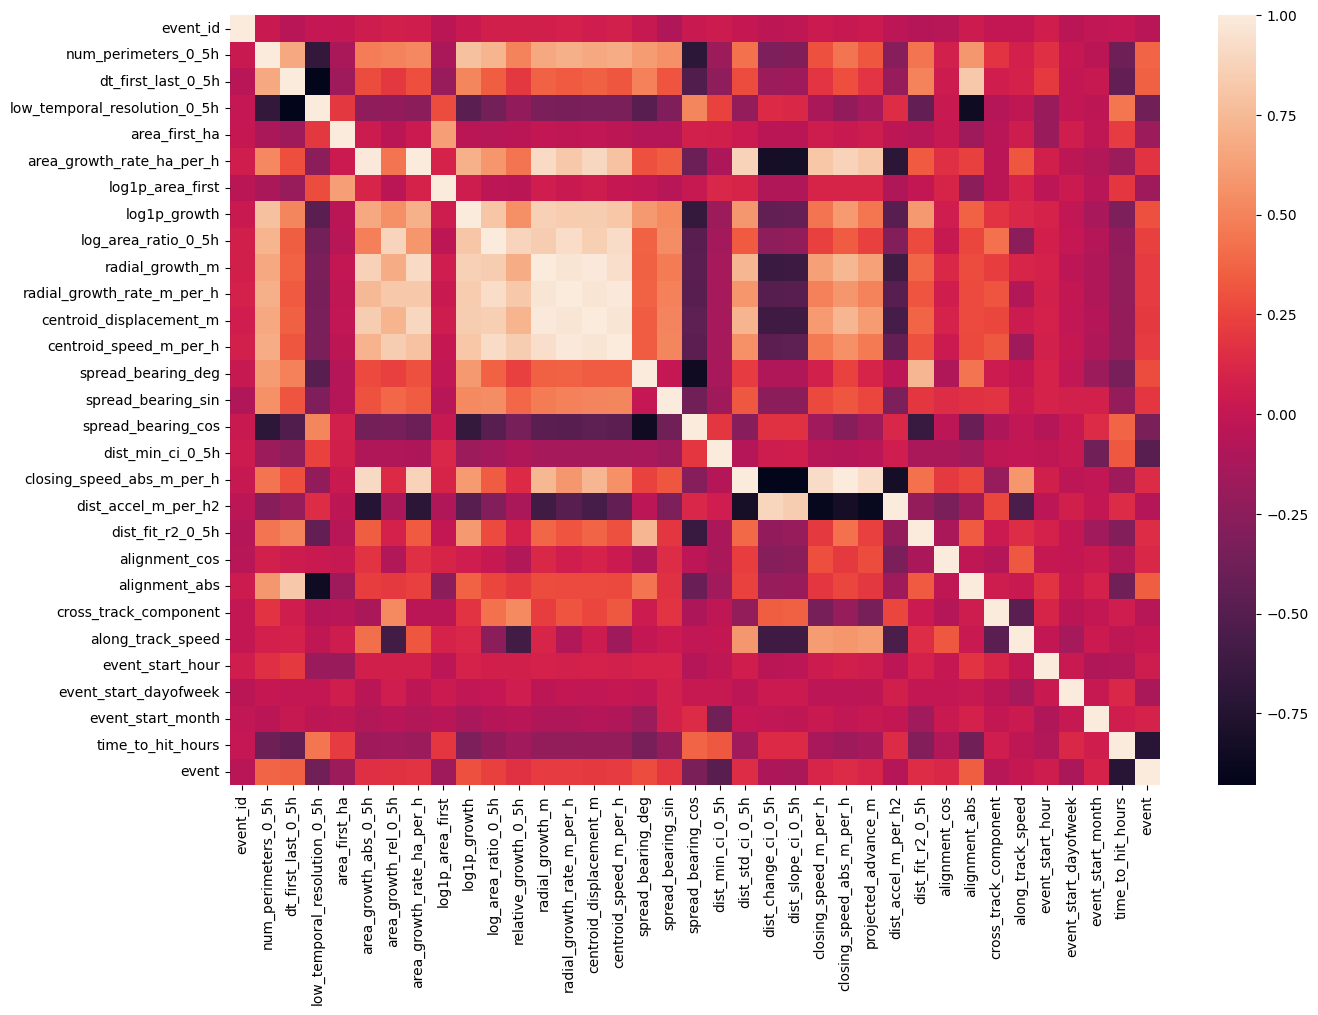

In [9]:
#this new heatmap has less highly correlated features (with the exception of the
#features with themselves) notice how heatmap looks less "square-y" and more
#"stripe-y"
new_corr_matrix = corr_matrix.drop(feats_to_remove)
plt.figure(figsize=(15, 10))
sns.heatmap(new_corr_matrix)

In [10]:
new_time_corr = new_corr_matrix['time_to_hit_hours']
new_clean_time_corr = new_time_corr.drop(index=['time_to_hit_hours', 'event']).abs()
new_sorted_time_corr = new_clean_time_corr.sort_values(ascending=False)
new_sorted_time_corr.head(25)

,time_to_hit_hours
low_temporal_resolution_0_5h,0.442236
dt_first_last_0_5h,0.434699
num_perimeters_0_5h,0.392040
spread_bearing_cos,0.370451
alignment_abs,0.366923
spread_bearing_deg,0.335598
dist_min_ci_0_5h,0.324876
log1p_growth,0.317451
dist_fit_r2_0_5h,0.284143
log_area_ratio_0_5h,0.228119


<Axes: xlabel='time_to_hit_hours', ylabel='Count'>

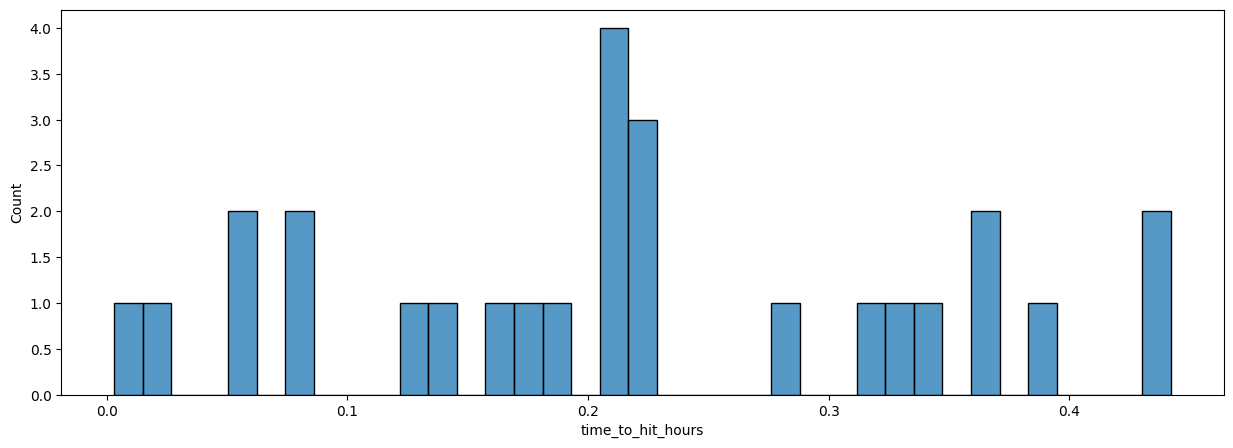

In [11]:
#viz on distribution of feature influence on time_to_hit_hours
plt.figure(figsize=(15, 5))
sns.histplot(data=new_sorted_time_corr, bins=37)

In [12]:
#decided to go with 0.1 as a filter value because 0.2 only left 16 features
#remaining and my NN will probably be able to handle more
above_corr = new_sorted_time_corr.loc[lambda x: x > 0.25]
num_feats = above_corr.shape[0]
num_feats

9

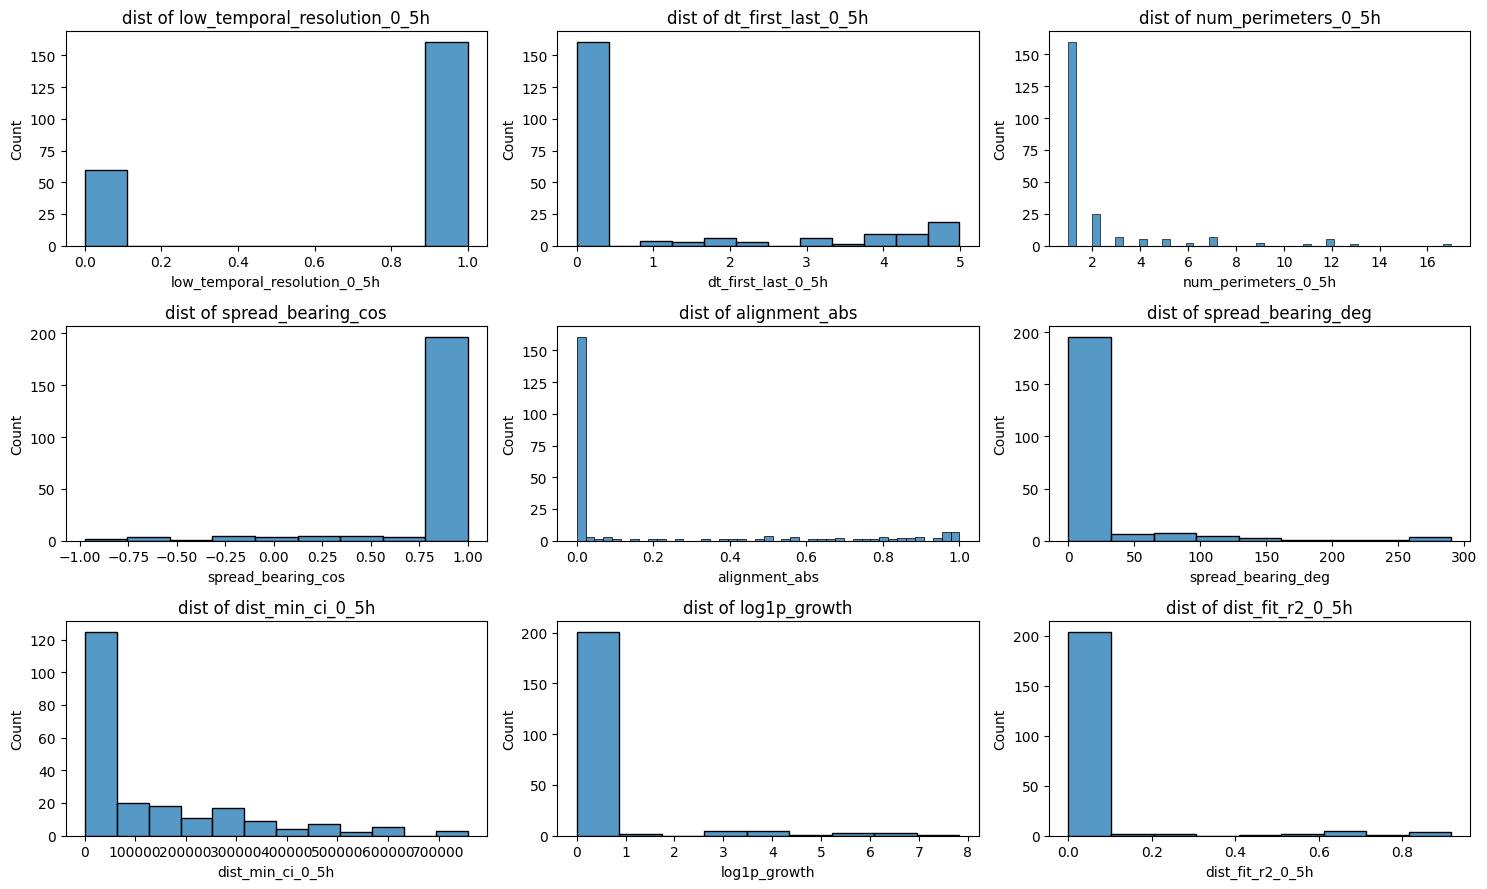

In [13]:
#AI disclaimer: this cell was generated by Google Gemini and edited by me
#it subplots for the most influential features in the dataset
cols = 3
rows = math.ceil(num_feats / cols)

fig, axs = plt.subplots(rows, cols, figsize=(15, rows * 3))
axs_flat = axs.flatten()

for i, feature in enumerate(above_corr.index):
    sns.histplot(data=train, x=feature, ax=axs_flat[i])
    axs_flat[i].set_title(f'dist of {feature}')

for j in range(i + 1, len(axs_flat)):
    axs_flat[j].axis('off')

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

train_copy = train.copy()
train_df, val_df = train_test_split(train_copy, test_size=0.2, random_state=42,
                                    shuffle=True)

test_df = test.copy()

# data prep and transormation

In [15]:
from sklearn import preprocessing

#low_temporal_resolution_0_5h - bounded
#dt_first_last_0_5h - short range
#num_perimeters_0_5h - short range
#spread_bearing_cos - bounded
#alignment_abs - bounded

#spread_bearing_deg - TODO: scale?
scaler1 = preprocessing.RobustScaler()
train_df['spread_bearing_deg'] = np.log1p(train_df['spread_bearing_deg'])
train_df['spread_bearing_deg'] = scaler1.fit_transform(train_df[['spread_bearing_deg']])

val_df['spread_bearing_deg'] = np.log1p(val_df['spread_bearing_deg'])
val_df['spread_bearing_deg'] = scaler1.transform(val_df[['spread_bearing_deg']])

test_df['spread_bearing_deg'] = np.log1p(test_df['spread_bearing_deg'])
test_df['spread_bearing_deg'] = scaler1.transform(test_df[['spread_bearing_deg']])

#dist_min_ci_0_5h
train_df['dist_min_ci_0_5h'] = np.log1p(train_df['dist_min_ci_0_5h'])

val_df['dist_min_ci_0_5h'] = np.log1p(val_df['dist_min_ci_0_5h'])

test_df['dist_min_ci_0_5h'] = np.log1p(test_df['dist_min_ci_0_5h'])

#log1p_growth - already transformed
#dist_fit_r2_0_5h - bounded
#log_area_ratio_0_5h - already transformed

#radial_growth_rate_m_per_h
scaler2 = preprocessing.RobustScaler()
train_df['radial_growth_rate_m_per_h'] = np.log1p(train_df['radial_growth_rate_m_per_h'])
train_df['radial_growth_rate_m_per_h'] = scaler2.fit_transform(train_df[['radial_growth_rate_m_per_h']])

val_df['radial_growth_rate_m_per_h'] = np.log1p(val_df['radial_growth_rate_m_per_h'])
val_df['radial_growth_rate_m_per_h'] = scaler2.transform(val_df[['radial_growth_rate_m_per_h']])

test_df['radial_growth_rate_m_per_h'] = np.log1p(test_df['radial_growth_rate_m_per_h'])
test_df['radial_growth_rate_m_per_h'] = scaler2.transform(test_df[['radial_growth_rate_m_per_h']])

#radial_growth_m
scaler3 = preprocessing.RobustScaler()
train_df['radial_growth_m'] = np.log1p(train_df['radial_growth_m'])
train_df['radial_growth_m'] = scaler3.fit_transform(train_df[['radial_growth_m']])

val_df['radial_growth_m'] = np.log1p(val_df['radial_growth_m'])
val_df['radial_growth_m'] = scaler3.transform(val_df[['radial_growth_m']])

test_df['radial_growth_m'] = np.log1p(test_df['radial_growth_m'])
test_df['radial_growth_m'] = scaler3.transform(test_df[['radial_growth_m']])

#spread_bearing_sin - bounded
#area_first_ha - already transformed by another feat
#log1p_area_first - transformed

#area_growth_rate_ha_per_h
scaler4 = preprocessing.RobustScaler()
train_df['area_growth_rate_ha_per_h'] = np.log1p(train_df['area_growth_rate_ha_per_h'])
train_df['area_growth_rate_ha_per_h'] = scaler4.fit_transform(train_df[['area_growth_rate_ha_per_h']])

val_df['area_growth_rate_ha_per_h'] = np.log1p(val_df['area_growth_rate_ha_per_h'])
val_df['area_growth_rate_ha_per_h'] = scaler4.transform(val_df[['area_growth_rate_ha_per_h']])

test_df['area_growth_rate_ha_per_h'] = np.log1p(test_df['area_growth_rate_ha_per_h'])
test_df['area_growth_rate_ha_per_h'] = scaler4.transform(test_df[['area_growth_rate_ha_per_h']])

#closing_speed_abs_m_per_h
scaler5 = preprocessing.RobustScaler()
train_df['closing_speed_abs_m_per_h'] = np.log1p(train_df['closing_speed_abs_m_per_h'])
train_df['closing_speed_abs_m_per_h'] = scaler5.fit_transform(train_df[['closing_speed_abs_m_per_h']])

val_df['closing_speed_abs_m_per_h'] = np.log1p(val_df['closing_speed_abs_m_per_h'])
val_df['closing_speed_abs_m_per_h'] = scaler5.transform(val_df[['closing_speed_abs_m_per_h']])

test_df['closing_speed_abs_m_per_h'] = np.log1p(test_df['closing_speed_abs_m_per_h'])
test_df['closing_speed_abs_m_per_h'] = scaler5.transform(test_df[['closing_speed_abs_m_per_h']])

#dist_accel_m_per_h2
yeo1 = preprocessing.PowerTransformer(method='yeo-johnson')
scaler6 = preprocessing.RobustScaler()
train_df['dist_accel_m_per_h2'] = yeo1.fit_transform(train_df[['dist_accel_m_per_h2']])
train_df['dist_accel_m_per_h2'] = scaler6.fit_transform(train_df[['dist_accel_m_per_h2']])

val_df['dist_accel_m_per_h2'] = yeo1.transform(val_df[['dist_accel_m_per_h2']])
val_df['dist_accel_m_per_h2'] = scaler6.transform(val_df[['dist_accel_m_per_h2']])

test_df['dist_accel_m_per_h2'] = yeo1.transform(test_df[['dist_accel_m_per_h2']])
test_df['dist_accel_m_per_h2'] = scaler6.transform(test_df[['dist_accel_m_per_h2']])

#event_start_dayofweek - irrelevant

#event_start_hour - TODO: cycle
def sin_cos_transformer(df):
  df['event_start_hour_sin'] = np.sin(2 * np.pi * df['event_start_hour'] / 24)
  df['event_start_hour_cos'] = np.cos(2 * np.pi * df['event_start_hour'] / 24)
  return df

train_df = sin_cos_transformer(train_df)
val_df = sin_cos_transformer(val_df)
test_df = sin_cos_transformer(test_df)


#cross_track_component
yeo2 = preprocessing.PowerTransformer(method='yeo-johnson')
train_df['cross_track_component'] = yeo2.fit_transform(train_df[['cross_track_component']])

val_df['cross_track_component'] = yeo2.transform(val_df[['cross_track_component']])

test_df['cross_track_component'] = yeo2.transform(test_df[['cross_track_component']])

In [16]:
feats_to_keep = np.array(above_corr.index)
feats_to_keep = np.append(feats_to_keep, 'event')
feats_to_keep = np.append(feats_to_keep, 'time_to_hit_hours')

preprocessed_train = train_df[feats_to_keep]
print(preprocessed_train.shape)
preprocessed_train.head()


(176, 11)


,low_temporal_resolution_0_5h,dt_first_last_0_5h,num_perimeters_0_5h,spread_bearing_cos,alignment_abs,spread_bearing_deg,dist_min_ci_0_5h,log1p_growth,dist_fit_r2_0_5h,event,time_to_hit_hours
218,0,3.710653,2,1.00000,0.694609,0.000000,8.704946,0.000000,0.000000,0,44.011253
113,0,4.499117,7,0.42799,0.231012,4.184489,8.116074,4.881102,0.072764,1,3.791231
140,0,3.768030,2,1.00000,0.495606,0.000000,13.257850,0.000000,0.000000,0,34.533803
122,1,0.000000,1,1.00000,0.000000,0.000000,11.021201,0.000000,0.000000,0,59.219647
162,1,0.000000,1,1.00000,0.000000,0.000000,7.289998,0.000000,0.000000,1,19.561849


In [17]:
preprocessed_val = val_df[feats_to_keep]
print(preprocessed_val.shape)
preprocessed_val.head()

(45, 11)


,low_temporal_resolution_0_5h,dt_first_last_0_5h,num_perimeters_0_5h,spread_bearing_cos,alignment_abs,spread_bearing_deg,dist_min_ci_0_5h,log1p_growth,dist_fit_r2_0_5h,event,time_to_hit_hours
132,1,0.000000,1,1.00000,0.000000,0.000000,11.934565,0.000000,0.0,0,66.640791
148,0,2.278508,2,1.00000,0.663145,0.000000,6.205765,0.000000,0.0,1,0.867177
93,1,0.000000,1,1.00000,0.000000,0.000000,13.269650,0.000000,0.0,0,17.636732
180,0,3.164563,17,-0.68927,0.637211,4.902102,6.334885,5.639406,0.0,1,3.274951
15,1,0.000000,1,1.00000,0.000000,0.000000,10.914328,0.000000,0.0,0,64.567485


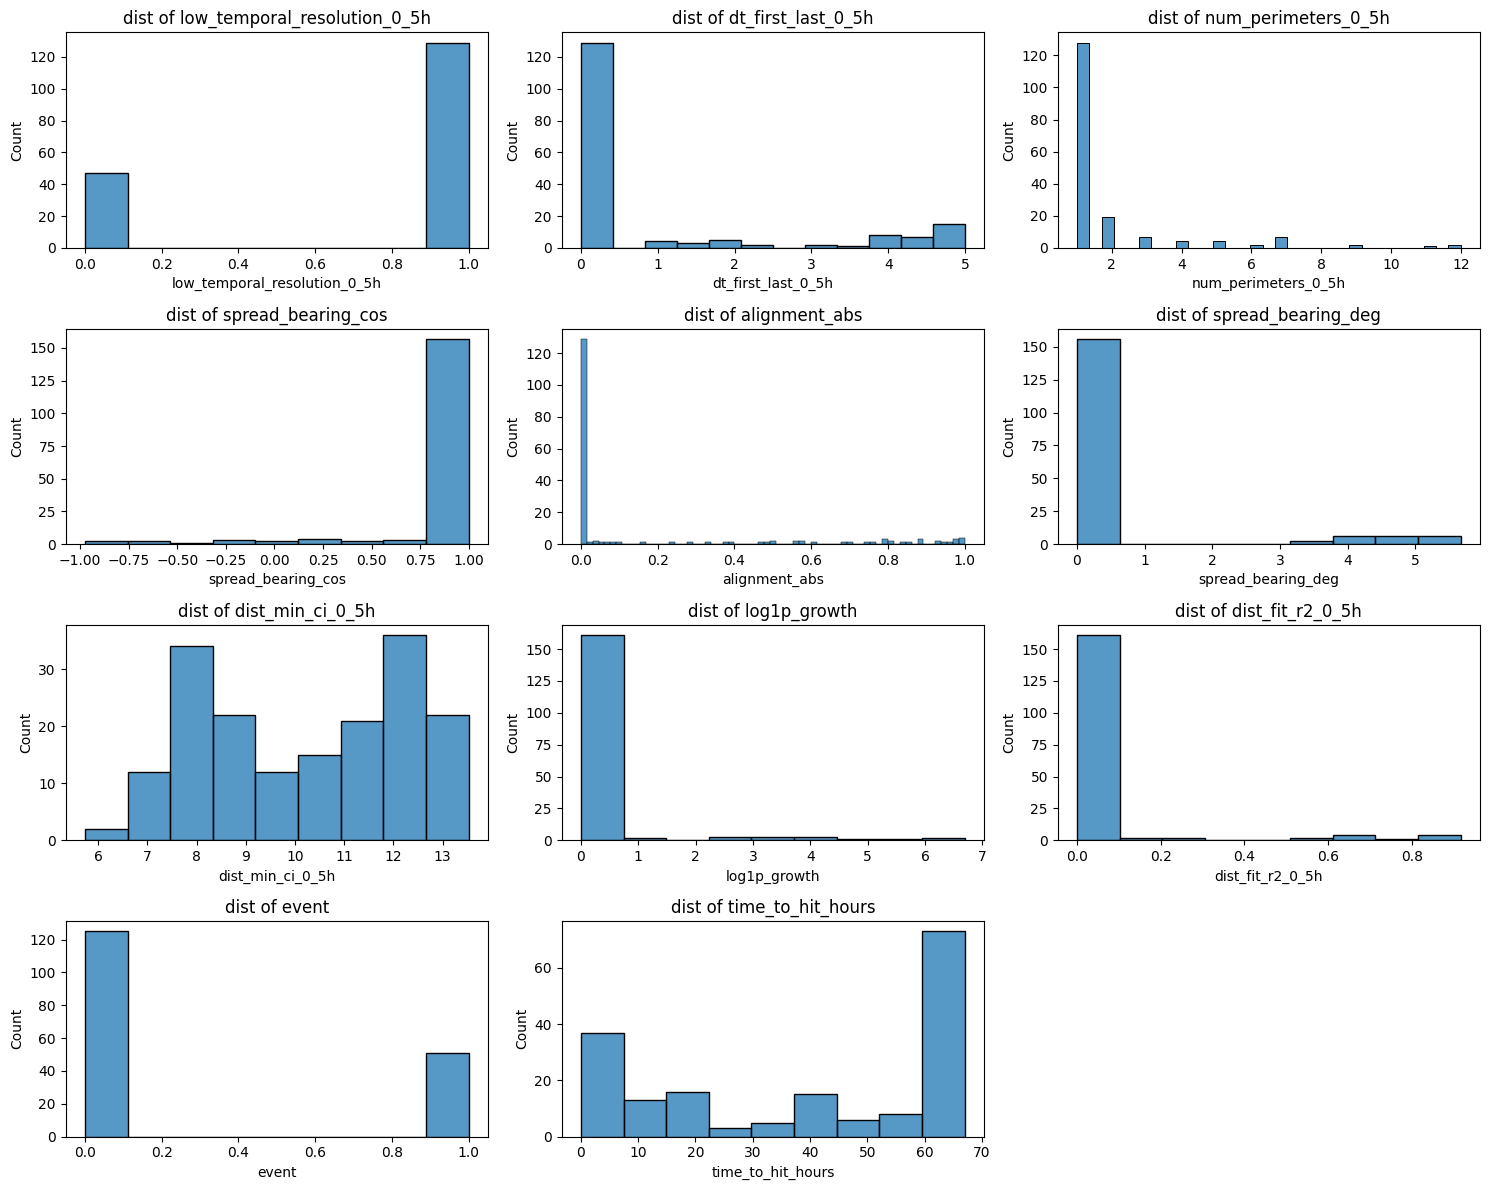

In [18]:
#AI disclaimer: this cell was generated by Google Gemini and edited by me
#it subplots for the most influential features in the dataset
processed_cols = 3
processed_rows = math.ceil(len(preprocessed_train.columns) / cols)

fig, axs = plt.subplots(processed_rows, processed_cols, figsize=(15, processed_rows * 3))
axs_flat = axs.flatten()

for i, feature in enumerate(preprocessed_train.columns):
    sns.histplot(data=preprocessed_train, x=feature, ax=axs_flat[i])
    axs_flat[i].set_title(f'dist of {feature}')

for j in range(i + 1, len(axs_flat)):
    axs_flat[j].axis('off')

plt.tight_layout()
plt.show()

<Axes: >

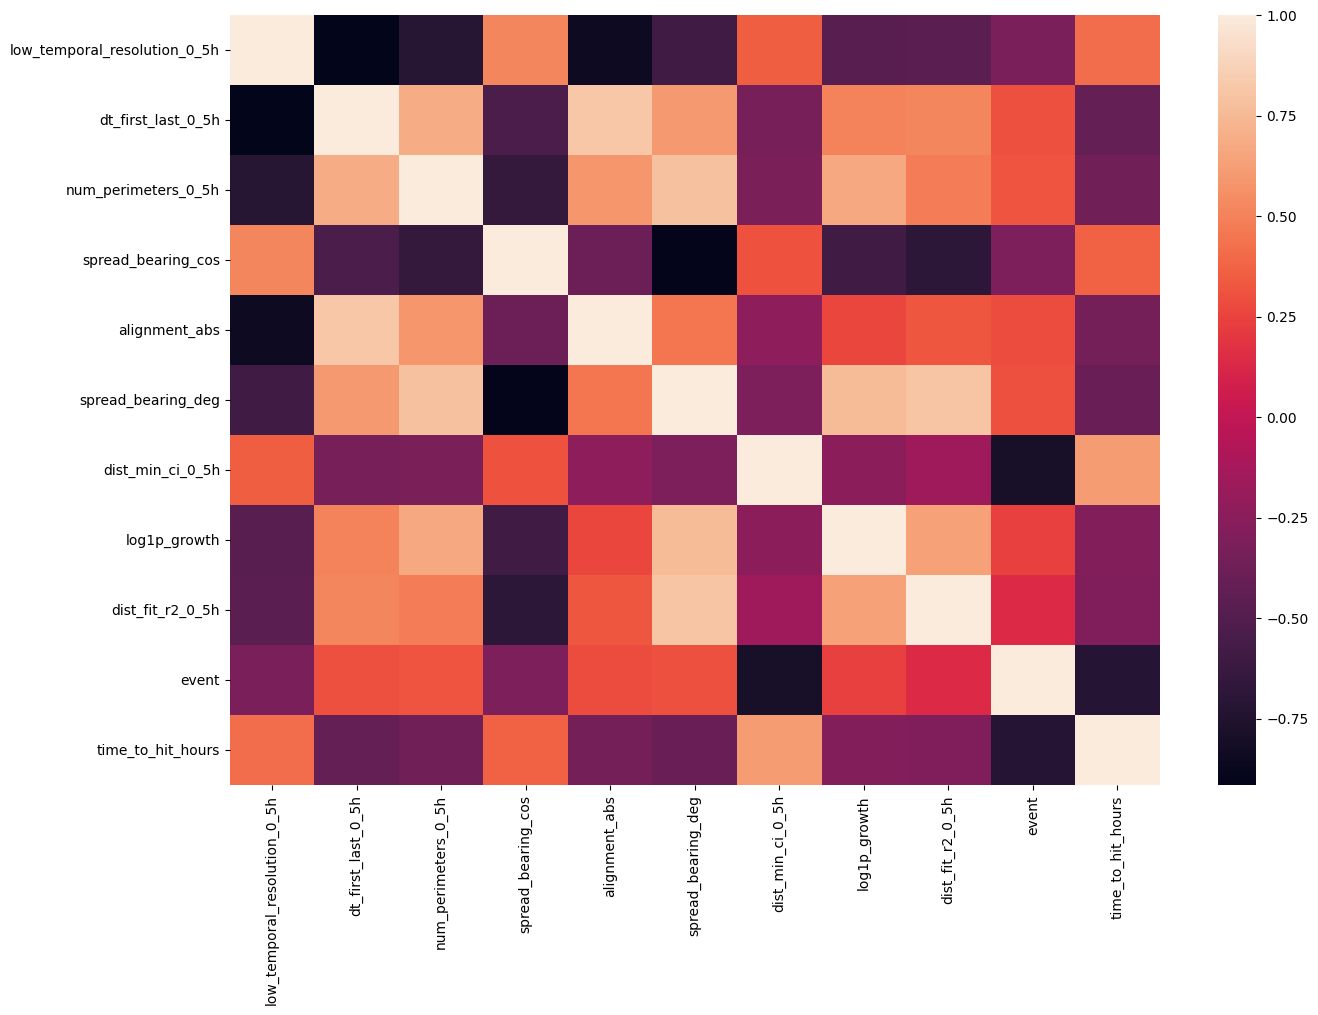

In [19]:
preprocessed_corr_matrix = preprocessed_train.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(preprocessed_corr_matrix)

In [20]:
def horizons(df):
  df['12h'] = (df['event'] == 1) & (df['time_to_hit_hours'] <= 12)
  df['12h'] = df['12h'].astype('int')

  df['24h'] = (df['event'] == 1) & (df['time_to_hit_hours'] <= 24) & (df['12h'] != True)
  df['24h'] = df['24h'].astype('int')

  df['48h'] = (df['event'] == 1) & (df['time_to_hit_hours'] <= 48) & (df['12h'] != True) & (df['24h'] != True)
  df['48h'] = df['48h'].astype('int')

  df['72h'] = (df['event'] == 1) & (df['time_to_hit_hours'] <= 72) & (df['12h'] != True) & (df['24h'] != True) & (df['48h'] != True)
  df['72h'] = df['72h'].astype('int')

  df['after72h'] = df['event'] == 0
  df['after72h'] = df['after72h'].astype('int')

  return df

# pytorch neural net

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

In [22]:
df_copy = preprocessed_train.copy()
train_w_horizons = horizons(df_copy)

y_train_df = train_w_horizons[['12h', '24h', '48h', '72h', 'after72h']]
X_train_df = train_w_horizons.drop(['12h', '24h', '48h', '72h', 'after72h',
                                    'event', 'time_to_hit_hours'], axis=1)

y_numpy = y_train_df.to_numpy()
X_numpy = X_train_df.to_numpy()

X_train = torch.tensor(X_numpy).float()
y_train = torch.tensor(y_numpy).float()

In [23]:
X_train.shape

torch.Size([176, 9])

In [24]:
in_feats = X_train.shape[1]

class PredictionNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.l1 = nn.Linear(in_feats, 128)
    self.relu1 = nn.ReLU()
    self.l2 = nn.Linear(128, 64)
    self.relu2 = nn.ReLU()
    self.l3 = nn.Linear(64, 5)

  def forward(self, x):
    x = self.l1(x)
    x = self.relu1(x)
    x = self.l2(x)
    x = self.relu2(x)
    x = self.l3(x)
    return x

In [25]:
model = PredictionNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [38]:
for epoch in range(1000):
    model.train()

    logits = model(X_train)
    #print(torch.softmax(logits, dim=1)[0])
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch + 1}/1000], Loss: {loss.item():.4f}')

Epoch [50/1000], Loss: 0.1541
Epoch [100/1000], Loss: 0.1527
Epoch [150/1000], Loss: 0.1514
Epoch [200/1000], Loss: 0.1500
Epoch [250/1000], Loss: 0.1487
Epoch [300/1000], Loss: 0.1474
Epoch [350/1000], Loss: 0.1463
Epoch [400/1000], Loss: 0.1452
Epoch [450/1000], Loss: 0.1442
Epoch [500/1000], Loss: 0.1433
Epoch [550/1000], Loss: 0.1425
Epoch [600/1000], Loss: 0.1419
Epoch [650/1000], Loss: 0.1412
Epoch [700/1000], Loss: 0.1405
Epoch [750/1000], Loss: 0.1399
Epoch [800/1000], Loss: 0.1393
Epoch [850/1000], Loss: 0.1387
Epoch [900/1000], Loss: 0.1384
Epoch [950/1000], Loss: 0.1378
Epoch [1000/1000], Loss: 0.1375


# running the model on validation set

In [39]:
df_val_copy = preprocessed_val.copy()
val_w_horizons = horizons(df_val_copy)

y_val_df = val_w_horizons[['12h', '24h', '48h', '72h', 'after72h']]
X_val_df = val_w_horizons.drop(['12h', '24h', '48h', '72h', 'after72h', 'event',
                                'time_to_hit_hours'], axis=1)

y_val_numpy = y_val_df.to_numpy()
X_val_numpy = X_val_df.to_numpy()

X_val = torch.tensor(X_val_numpy).float()
y_val = torch.tensor(y_val_numpy).float()

In [40]:
model.eval()
with torch.no_grad():
    val_predictions = model(X_val)

In [41]:
val_probabilities = torch.softmax(val_predictions, dim=1)

In [42]:
val_predictions_numpy = val_probabilities.detach().numpy()
val_pred = pd.DataFrame(val_predictions_numpy)
val_pred.columns = ['12h', '24h', '48h', '72h', 'after72h']
val_pred.head()

,12h,24h,48h,72h,after72h
0,5.003704e-33,8.308193e-35,2.023335e-40,0.000000e+00,1.000000e+00
1,1.000000e+00,4.007209e-13,9.088387e-14,5.145414e-14,3.023222e-15
2,2.942727e-44,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
3,1.000000e+00,2.966478e-38,3.585942e-34,1.006105e-34,4.930526e-26
4,1.902064e-24,3.262411e-26,6.140904e-30,1.714472e-36,1.000000e+00


In [50]:
#AI disclaimer: this cell was generated by Google Gemini and edited by me to test model accuracy

max_cols = val_pred.idxmax(axis=1)

val_one_hot = pd.DataFrame(0, index=val_pred.index, columns=val_pred.columns)
for idx, col in max_cols.items():
    val_one_hot.loc[idx, col] = 1

mask = np.isclose(y_val, val_one_hot, atol=1e-5)
accuracy = mask.mean()
print(accuracy)

0.9466666666666667


# making predictions on the test set

In [32]:
test_feats_to_keep = np.array(above_corr.index)

preprocessed_test = test_df[test_feats_to_keep]
preprocessed_test.head()

,low_temporal_resolution_0_5h,dt_first_last_0_5h,num_perimeters_0_5h,spread_bearing_cos,alignment_abs,spread_bearing_deg,dist_min_ci_0_5h,log1p_growth,dist_fit_r2_0_5h
0,1,0.000000,1,1.000000,0.00000,0.000000,11.669434,0.000000,0.000000
1,1,0.000000,1,1.000000,0.00000,0.000000,7.912695,0.000000,0.000000
2,1,0.000000,1,1.000000,0.00000,0.000000,10.054971,0.000000,0.000000
3,1,0.000000,1,1.000000,0.00000,0.000000,7.783077,0.000000,0.000000
4,0,3.459331,7,0.084344,0.15855,4.456226,10.200512,2.603921,0.044572


In [33]:
test_numpy = preprocessed_test.to_numpy()
X_test = torch.tensor(test_numpy).float()

X_test.shape

torch.Size([95, 9])

In [34]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    #print(f'Predictions:\n{predictions}')

In [35]:
probabilities = torch.softmax(predictions, dim=1)

test_predictions_numpy = probabilities.detach().numpy()
final_pred = pd.DataFrame(test_predictions_numpy)
final_pred.columns = ['12h', '24h', '48h', '72h', 'after72h']
final_pred['event_id'] = test['event_id']
final_pred.head()

,12h,24h,48h,72h,after72h,event_id
0,4.628126e-19,2.054437e-21,9.419872e-21,1.754912e-25,1.000000,10662602
1,5.992735e-01,2.564957e-01,9.284469e-02,5.073455e-02,0.000652,13353600
2,2.852907e-10,7.722687e-12,2.272050e-11,3.499244e-14,1.000000,13942327
3,5.555769e-01,2.852961e-01,8.925493e-02,6.976712e-02,0.000105,16112781
4,9.769283e-06,4.638910e-14,8.808739e-16,6.401063e-19,0.999990,17132808


In [36]:
final_pred['prob_12h'] = final_pred['12h']
final_pred['prob_24h'] = final_pred['24h']
final_pred['prob_48h'] = final_pred['48h']
final_pred['prob_72h'] = final_pred['72h']

test_csv = final_pred[['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']]
test_csv.head()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,4.628126e-19,2.054437e-21,9.419872e-21,1.754912e-25
1,13353600,5.992735e-01,2.564957e-01,9.284469e-02,5.073455e-02
2,13942327,2.852907e-10,7.722687e-12,2.272050e-11,3.499244e-14
3,16112781,5.555769e-01,2.852961e-01,8.925493e-02,6.976712e-02
4,17132808,9.769283e-06,4.638910e-14,8.808739e-16,6.401063e-19


In [37]:
test_csv.to_csv('test.csv', index=False)

# pca (if i want to revisit the project)

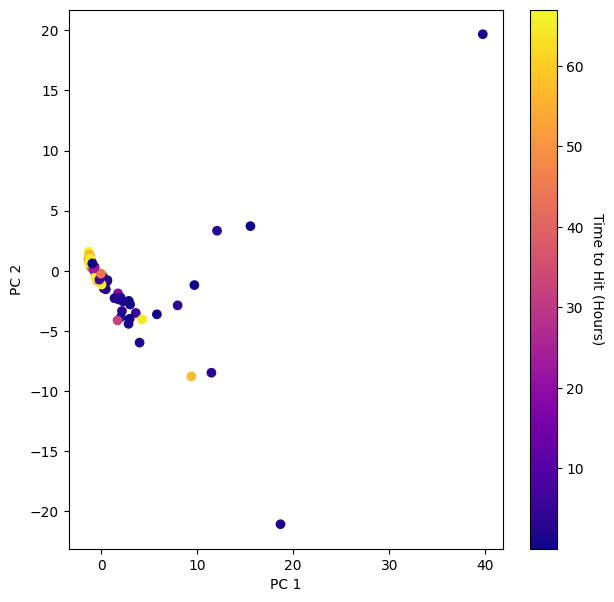

In [52]:
#saving this for later... could be useful if i revisit this project
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(train)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

plt.figure(figsize=(7,7))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], c=train['time_to_hit_hours'], cmap='plasma')

cbar = plt.colorbar(scatter)
cbar.set_label('Time to Hit (Hours)', rotation=270, labelpad=15)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()